### Name: Se Rang Seo
### Assignment 10: PCA and LLE

### Instruction:
Return to the SDSS spectra with PCA exercise discussed in Acquaviva Sec. 7.4.2 and in class.

Notebook: PCA_spectra.ipynb Download PCA_spectra.ipynb  data file:  spec4000_corrected.npzDownload spec4000_corrected.npz

Figure out how many PCA components are needed to keep all spectra below the 10% fractional difference line.
Repeat the exercise with local linear embedding (LLE) instead of PCA.  You may reference this exampleLinks to an external site. from IvezićLinks to an external site. for tips.

# Imports

In [1]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt

from sklearn import preprocessing, decomposition
#!pip install scikit-image
import skimage
from skimage.transform import resize, rescale
from skimage import io

ModuleNotFoundError: No module named 'numpy'

# Data

In [ ]:
data = np.load('spec4000_corrected.npz')

data

NpzFile 'spec4000_corrected.npz' with keys: y, X, labels, z, wavelengths

In [ ]:
wavelengths = data['wavelengths']
X = data['X']
y = data['y']
labels = data['labels'].astype('str')

In [ ]:
X.shape

(4000, 1000)

# PCA

In [ ]:
#  Perform PCA
scaler = preprocessing.StandardScaler() #It's important that data are centered!
Xn = scaler.fit_transform(X) #This is a standardization procedure.

comp = 962

pca = decomposition.PCA(n_components=comp, random_state=0)
X_proj = pca.fit_transform(Xn) #the projected data set - it lives in a new feature space with 4,000 objects and 1000 features

# Difference

In [ ]:
Xrec = pca.inverse_transform(X_proj) #This is useful for a sanity check; there should be no information loss, modulo numerical precision issues

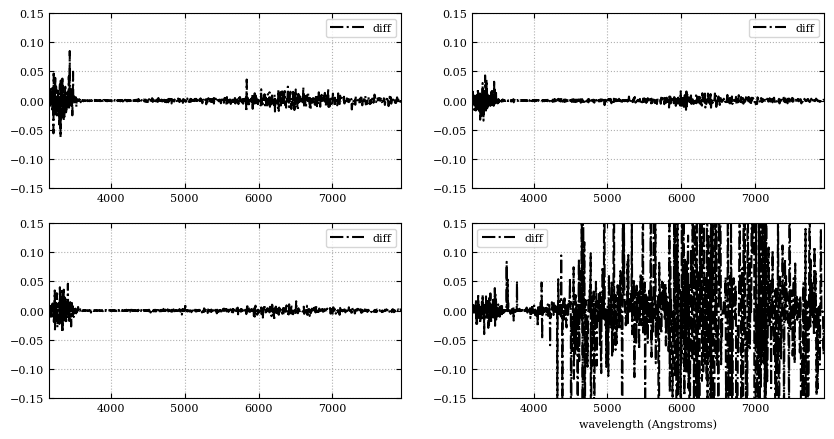

In [ ]:
fig3 = plt.figure(figsize=(10,5))

for i in range(4,8):
    plt.subplot(2,2,i-3)
    plt.plot(wavelengths, (Xrec[i]-Xn[i])/Xn[i], '-.', label = 'diff', c = 'k')
    plt.grid(True)
    plt.ylim(-.15,.15)
    plt.legend();
plt.xlabel('wavelength (Angstroms)');

# Comp for under 10%

The only way to get the 4th plot not freak out is when I maxed the components to 1000.

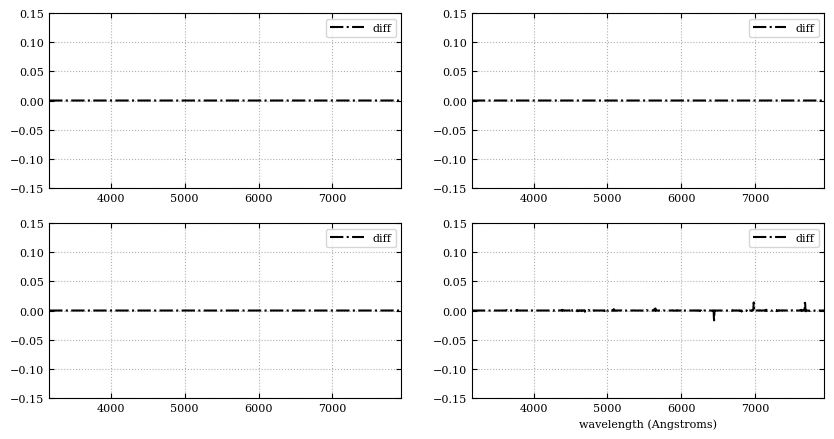

In [ ]:
comp = 1000
pca = decomposition.PCA(n_components=comp, random_state=0)
X_proj = pca.fit_transform(Xn) #the projected data set - it lives in a new feature space with 4,000 objects and 1000 features

Xrec = pca.inverse_transform(X_proj) #This is useful for a sanity check; there should be no information loss, modulo numerical precision issues

fig3 = plt.figure(figsize=(10,5))

for i in range(4,8):
    plt.subplot(2,2,i-3)
    plt.plot(wavelengths, (Xrec[i]-Xn[i])/Xn[i], '-.', label = 'diff', c = 'k')
    plt.grid(True)
    plt.ylim(-.15,.15)
    plt.legend();
plt.xlabel('wavelength (Angstroms)');

# LLE (Local Linear Embedding)

### Imports

In [ ]:
from matplotlib import pyplot as plt
from sklearn import manifold, neighbors, decomposition
from sklearn.neighbors import NearestNeighbors

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

### Managing Data

In [ ]:
Xn = data['X']

# If labels is a 1D array, use it directly
if hasattr(labels, 'shape') and len(labels.shape) == 1 and labels.shape[0] == Xn.shape[0]:
    labels_str = labels.astype('str')
else:
    # If labels is not matching, create from y or use default
    labels_str = y.astype('str')
    
# Fit LLE
print("\nFitting LLE...")
lle = manifold.LocallyLinearEmbedding(n_neighbors=10, n_components=3, method='standard')
Y_LLE = lle.fit_transform(Xn)

# Remove outliers
BT = neighbors.BallTree(Y_LLE)
dist, ind = BT.query(Y_LLE, 10)
dist_to_n = dist[:, -1]
dist_to_n -= dist_to_n.mean()
std = np.std(dist_to_n)
flag = (dist_to_n > 0.25 * std)

# Filter data - make sure all arrays have same length
coeffs_LLE = Y_LLE[~flag]
y_LLE = y[~flag]
labels_LLE = labels_str[~flag]


Fitting LLE...


### Plot LLE

C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_27220\3014417110.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet', n_labels)


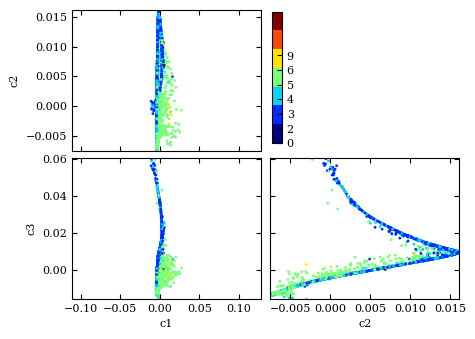

In [ ]:
if len(coeffs_LLE) > 0:
    unique_labels = np.unique(labels_LLE)
    n_labels = len(unique_labels)
    cmap = plt.cm.get_cmap('jet', n_labels)

    fig = plt.figure(figsize=(5, 3.75))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    cax = plt.axes([0.525, 0.525, 0.02, 0.35])
    scatter_kwargs = dict(s=4, lw=0, edgecolors='none', c=y_LLE, cmap=cmap)

    xlim = (coeffs_LLE[:, 0].min() - 0.1, coeffs_LLE[:, 0].max() + 0.1)

    ax1 = plt.subplot(221)
    im1 = ax1.scatter(coeffs_LLE[:, 0], coeffs_LLE[:, 1], **scatter_kwargs)
    im1.set_clim(y_LLE.min(), y_LLE.max())
    ax1.set_ylabel('c2')

    ax2 = plt.subplot(223)
    im2 = ax2.scatter(coeffs_LLE[:, 0], coeffs_LLE[:, 2], **scatter_kwargs)
    im2.set_clim(y_LLE.min(), y_LLE.max())
    ax2.set_xlabel('c1')
    ax2.set_ylabel('c3')

    ax3 = plt.subplot(224);
    im3 = ax3.scatter(coeffs_LLE[:, 1], coeffs_LLE[:, 2], **scatter_kwargs)
    im3.set_clim(y_LLE.min(), y_LLE.max())
    ax3.set_xlabel('c2')

    fig.colorbar(im3, ax=ax3, cax=cax,
                 ticks=range(len(unique_labels)),
                 format=plt.FuncFormatter(lambda t, *args: unique_labels[int(t)] if int(t) < len(unique_labels) else ''));

    ax1.xaxis.set_major_formatter(plt.NullFormatter());
    ax3.yaxis.set_major_formatter(plt.NullFormatter());

    ax1.set_xlim(xlim)
    ax2.set_xlim(xlim)

    for ax in (ax1, ax2, ax3):
        ax.xaxis.set_major_locator(plt.MaxNLocator(5));
        ax.yaxis.set_major_locator(plt.MaxNLocator(5));

    plt.show()
else:
    print("No samples to plot");

### Try different components

Trying 5 components... ✗ Preservation: 0.334 | Error: 0.666 | Component: 5
Trying 50 components... ✗ Preservation: 0.498 | Error: 0.502 | Component: 50
Trying 100 components... ✗ Preservation: 0.522 | Error: 0.478 | Component: 100
Trying 200 components... ✗ Preservation: 0.544 | Error: 0.456 | Component: 200
Trying 300 components... ✗ Preservation: 0.550 | Error: 0.450 | Component: 300
Trying 400 components... ✗ Preservation: 0.547 | Error: 0.453 | Component: 400
Trying 500 components... ✗ Preservation: 0.541 | Error: 0.459 | Component: 500
Trying 700 components... ✗ Preservation: 0.528 | Error: 0.472 | Component: 700
Trying 800 components... ✗ Preservation: 0.521 | Error: 0.479 | Component: 800
Trying 1000 components... ✗ Preservation: 0.509 | Error: 0.491 | Component: 1000


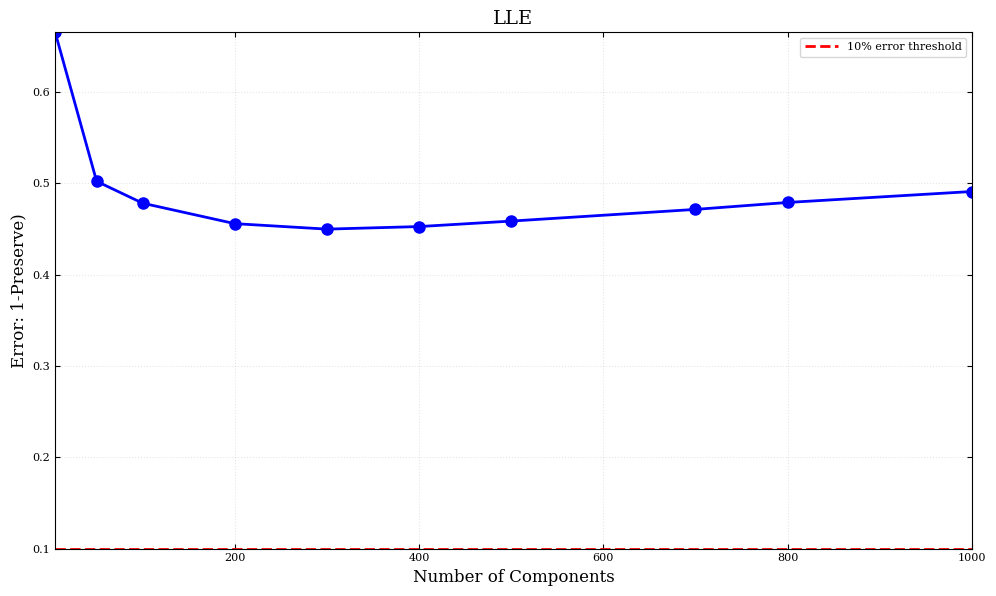

In [ ]:
# Test different numbers of components
n_components_to_try = [5,50, 100, 200, 300, 400, 500, 700, 800, 1000]
neighborhood_errors = []

for n_comp in n_components_to_try:
    print(f"Trying {len(n_comp)} components...", end=" ")
    
    # Fit LLE
    lle = manifold.LocallyLinearEmbedding(
        n_neighbors=min(15, n_comp*2 if n_comp>0 else 15), 
        n_components=n_comp,
        method='standard'
    )
    Y_LLE = lle.fit_transform(Xn)
    
    # Check neighborhood preservation (what LLE actually optimizes)
    # For each point, check if its nearest neighbors in LLE space are also its neighbors in original space
    
    nbrs_orig = NearestNeighbors(n_neighbors=10).fit(Xn)
    nbrs_lle = NearestNeighbors(n_neighbors=10).fit(Y_LLE)
    
    # Sample points
    np.random.seed(42)
    n_samples = min(500, len(Xn))
    sample_indices = np.random.choice(len(Xn), n_samples, replace=False)
    
    preservation_rates = []
    for idx in sample_indices:
        # Get neighbors in original space
        _, orig_neighbors = nbrs_orig.kneighbors(Xn[idx:idx+1])
        # Get neighbors in LLE space
        _, lle_neighbors = nbrs_lle.kneighbors(Y_LLE[idx:idx+1])
        
        # What fraction of LLE neighbors are also original neighbors?
        n_keep = 5  # Check top 5 neighbors
        overlap = len(set(orig_neighbors[0][:n_keep]) & set(lle_neighbors[0][:n_keep]))
        preservation = overlap / n_keep
        preservation_rates.append(preservation)
    
    avg_preservation = np.mean(preservation_rates)
    error = 1 - avg_preservation
    neighborhood_errors.append(error)
    
    status = "✓" if error < 0.1 else "✗"
    print(f"{status} Preservation: {avg_preservation:.3f} | Error: {error:.3f} | Component: {n_comp}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_components_to_try, neighborhood_errors, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.1, color='r', linestyle='--', label='10% error threshold', linewidth=2)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Error: 1-Preserve)', fontsize=12)
plt.title('LLE', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

I've tried other neighbors nums but I couldn't find ones that would get me lower to 0.1. Best component is 300.